## Human In the loop

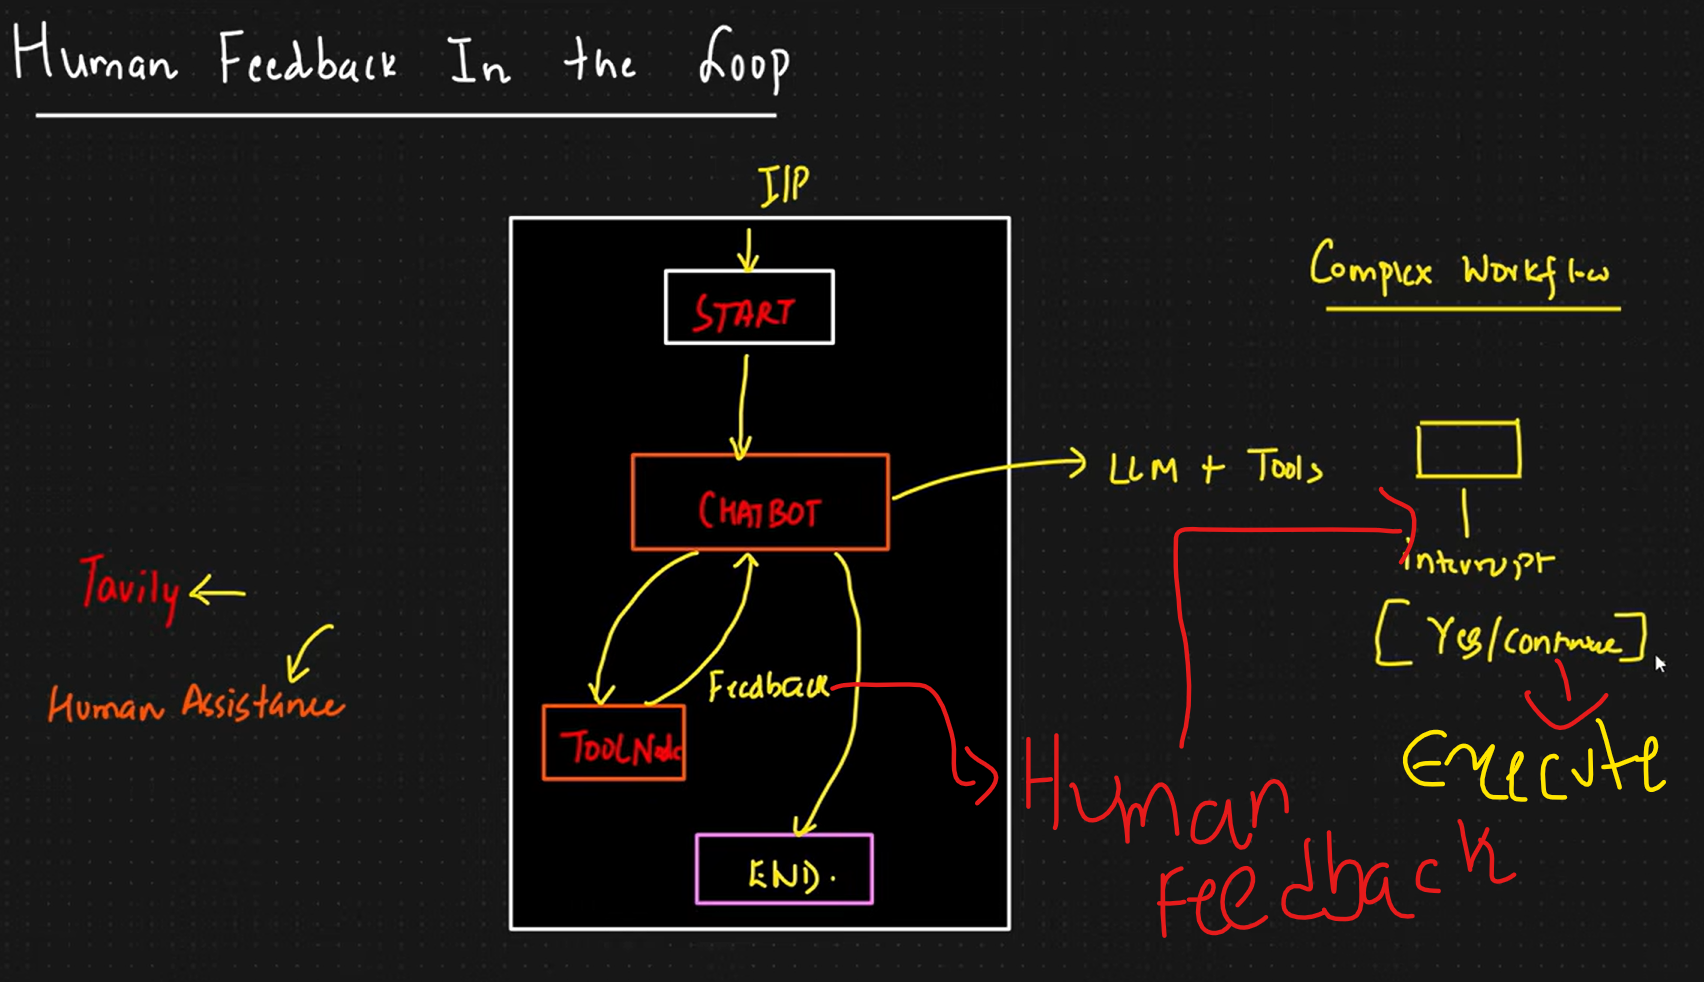

In [1]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage, HumanMessage,AIMessage
import os
from dotenv import load_dotenv


load_dotenv()

model = ChatOpenAI(
    model="prism-ml/ternary-bonsai-2-27b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    max_tokens=1000,
)

In [11]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt


class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder= StateGraph(State)

@tool       # Tool Number 1
def human_assistance(query:str)->str:
    """Request assistance from a human"""
    human_response= interrupt({"query":query})
    return human_response["data"]

# Tool number 2
tool=TavilySearch(max_results=2) 

#Binding tools
tools= [human_assistance, tool]
llm_with_tools=model.bind_tools(tools)  

def chatbot(state:State):
    messages = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume
    return {"messages": messages}

graph_builder.add_node("chatbot", chatbot)

tool_node=ToolNode(tools=tools)

graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot",tools_condition,)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")




In [12]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

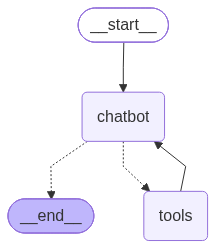

In [13]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:

user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_2F589E9ABA3B4883AEB448A9)
 Call ID: call_2F589E9ABA3B4883AEB448A9
  Args:
    query: I need expert guidance and assistance for building an AI agent. I'd like a human expert to help me with the architecture, tooling, and best practices for developing an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_2F589E9ABA3B4883AEB448A9)
 Call ID: call_2F589E9ABA3B4883AEB448A9
  Args:
    query: I need expert guidance and assistance for building an AI agent. I'd like a human expert to help me with the architecture, tooling, and best practices for developing an AI agent.


In [15]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_2F589E9ABA3B4883AEB448A9)
 Call ID: call_2F589E9ABA3B4883AEB448A9
  Args:
    query: I need expert guidance and assistance for building an AI agent. I'd like a human expert to help me with the architecture, tooling, and best practices for developing an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================



I've connected you with our experts! Here's what they shared:

**Recommendation: LangGraph**

The experts advise you to look into **LangGraph** for building your agent. They highlighted that LangGraph offers significantly better reliability and extensibility compare